|<img style="float:left;" src="../images/usherb_transp.gif" width=90% height=90%> |<big>Pierre Proulx, ing, professeur</big>|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|


### Problème 10B2, 

### Presque identique à la section 10.4, on peut utiliser sympy pour aller plus loin dans l'analyse des résultats

In [1]:
#
# Pierre Proulx
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp          
from IPython.display import *
sp.init_printing(use_latex=True)
%matplotlib inline

In [2]:
# Paramètres, variables et fonctions
#
mu,k,b,T0,vb,x=sp.symbols('mu k b T_0 v_b x')
T=sp.Function('T')(x)
v=sp.Function('v')(x)

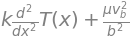

In [3]:
v=vb*x/b
eq=k*T.diff(x,x)+mu*v.diff(x)**2
display(eq)

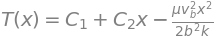

In [4]:
T=sp.dsolve(eq)
display(T)

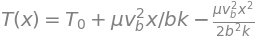

In [5]:
eq1=sp.Eq(T.rhs.subs(x,0),T0)
eq2=sp.Eq(T.rhs.diff(x).subs(x,b),0)     #####modification par rapport a la section 10.4###
display(eq1)
display(eq2)
constantes=sp.solve((eq1,eq2),('C1','C2'))
display(constantes)
T=T.subs(constantes)
display(T)

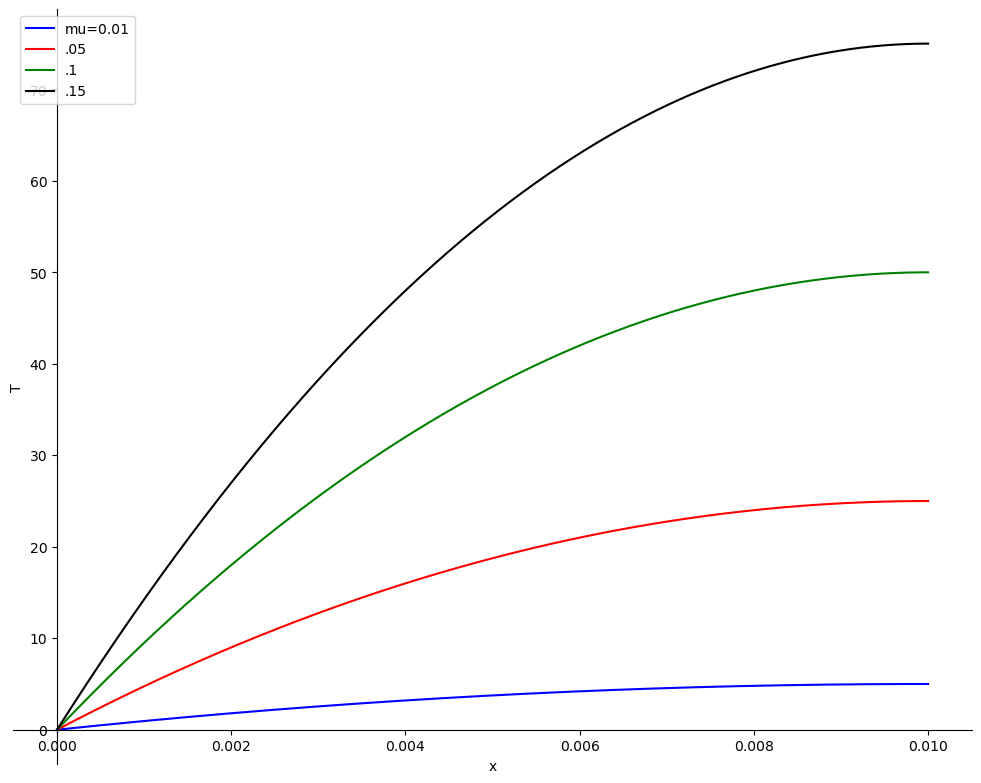

In [6]:
### Tracage
T=T.rhs
dico={'T_0':0,'k':0.1,'mu':0.01,'b':0.01,'v_b':10}
T1=T.subs(dico)
dico={'T_0':0,'k':0.1,'mu':0.05,'b':0.01,'v_b':10}
T2=T.subs(dico)
dico={'T_0':0,'k':0.1,'mu':0.1,'b':0.01,'v_b':10}
T3=T.subs(dico)
dico={'T_0':0,'k':0.1,'mu':0.15,'b':0.01,'v_b':10}
T4=T.subs(dico)
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=10,8
p=sp.plot((T1,(x,0,0.01)),(T2,(x,0,0.01)),(T3,(x,0,0.01)),(T4,(x,0,0.01)),
       legend=True,ylabel='T',xlabel='x',show=False)
p[0].label='mu=0.01'
p[1].label='.05'
p[2].label='.1'
p[3].label='.15'
p[0].line_color='blue'
p[1].line_color='red'
p[2].line_color='green'
p[3].line_color='black'
p.show()